In [182]:
import pandas as pd
import numpy as np
#from IPython.display import HTML
year = 2024

In [183]:
plant_860 = pd.read_excel("/Users/mshaaban/clab_underground_th_storage/Finding_IRL_MISO_CFs/eia860"+str(year)+"/2___Plant_Y"+str(year)+".xlsx", skiprows=1)
generator_860 = pd.read_excel("/Users/mshaaban/clab_underground_th_storage/Finding_IRL_MISO_CFs/eia860"+str(year)+"/3_1_Generator_Y"+str(year)+".xlsx", sheet_name="Operable" , skiprows=1)

In [184]:
plant_860[plant_860["Balancing Authority Code"] == "MISO"].to_excel("plants_only_miso_"+str(year)+".xlsx", index=True)

coal_codes = ["ANT", "BIT", "SUB", "LIG", "RC", "WC", "SC", "SGC"]

generator_860[
    (generator_860["Energy Source 1"].isin(coal_codes)) &
    (generator_860["Status"] == "OP")
].to_excel("generators_only_coal_" + str(year) + ".xlsx", index=True)

In [185]:
miso_plants = pd.read_excel("plants_only_miso_"+str(year)+".xlsx")
coal_gens = pd.read_excel("generators_only_coal_"+str(year)+".xlsx")

In [186]:
results = []
merged_row = 0

coal_codes = ["ANT", "BIT", "SUB", "LIG", "RC", "WC", "SC", "SGC"]

for i in range(len(miso_plants)):
    plant_code = miso_plants["Plant Code"].iloc[i]
    matches = coal_gens[coal_gens["Plant Code"] == plant_code]

    if not matches.empty:
        # Single generator — simple combine
        if len(matches) == 1:
            plant_row = miso_plants.iloc[[i]].reset_index(drop=True)
            for _, gen_row in matches.iterrows():
                gen_row_df = pd.DataFrame([gen_row]).reset_index(drop=True)
                combined = pd.concat([gen_row_df, plant_row], axis=1)
                results.append(combined)
                merged_row += 1

        # Multiple generators — aggregate all coal units together
        else:
            coal = []
            for j in range(len(matches)):
                fuel = matches["Energy Source 1"].iloc[j]
                if fuel in coal_codes:
                    coal.append(matches.iloc[j])

            if coal:
                coal_df  = pd.DataFrame(coal).reset_index(drop=True)
                coal_agg = coal_df.iloc[[0]].copy()
                coal_agg["Summer Capacity (MW)"] = (
                    pd.to_numeric(coal_df["Summer Capacity (MW)"], errors="coerce")
                    .fillna(0)
                    .sum()
                )
                plant_row = miso_plants.iloc[[i]].reset_index(drop=True)
                combined  = pd.concat([coal_agg.reset_index(drop=True), plant_row], axis=1)
                results.append(combined)
                merged_row += 1

final = pd.concat(results, ignore_index=True)
final.to_excel("merged_MISO_coal_" + str(year) + ".xlsx", index=False)
print("Total matches:", merged_row)

Total matches: 58


In [187]:
miso_coal_plants = pd.read_excel("MISO_coal_plants_output.xlsx")

In [188]:
coal_coords_new = []
coal_coords_old = []
for i in range(len(miso_coal_plants)):
    lat = miso_coal_plants["Latitude"].iloc[i]
    lon = miso_coal_plants["Longitude"].iloc[i]
    name = miso_coal_plants["Plant Name"].iloc[i]
    capacity = miso_coal_plants["Nameplate Capacity (MW)"].iloc[i]

    item = {"lat": lat, "lon": lon, "label": name, "capacity": capacity}
    if miso_coal_plants["Operating Year"].iloc[i] > 1980:
        coal_coords_new.append(item)
    else:
        coal_coords_old.append(item)

print("New coal plants:")
print(coal_coords_new)
print("Old coal plants:")
print(coal_coords_old)

New coal plants:
[{'lat': 44.8606, 'lon': -89.6553, 'label': 'Weston', 'capacity': 350.5}, {'lat': 34.4228, 'lon': -92.1406, 'label': 'White Bluff', 'capacity': 900.0}, {'lat': 30.7261, 'lon': -91.3692, 'label': 'Big Cajun 2', 'capacity': 657.9}, {'lat': 41.0961, 'lon': -92.555833, 'label': 'Ottumwa', 'capacity': 725.9}, {'lat': 47.221447, 'lon': -101.815722, 'label': 'Coyote', 'capacity': 450.0}, {'lat': 30.2844, 'lon': -93.2911, 'label': 'R S Nelson', 'capacity': 614.6}, {'lat': 38.372222, 'lon': -87.765833, 'label': 'Gibson', 'capacity': 667.9}, {'lat': 31.395, 'lon': -92.716667, 'label': 'Brame Energy Center', 'capacity': 558.0}, {'lat': 39.0694, 'lon': -87.5108, 'label': 'Merom', 'capacity': 540.0}, {'lat': 41.3917, 'lon': -91.0569, 'label': 'Muscatine Plant #1', 'capacity': 175.5}, {'lat': 30.7261, 'lon': -91.3692, 'label': 'Big Cajun 2', 'capacity': 619.0}, {'lat': 41.2164, 'lon': -87.0261, 'label': 'R M Schahfer', 'capacity': 423.5}, {'lat': 39.0694, 'lon': -87.5108, 'label': '

ValueError: Can not reset the axes.  You are probably trying to re-use an artist in more than one Axes which is not supported

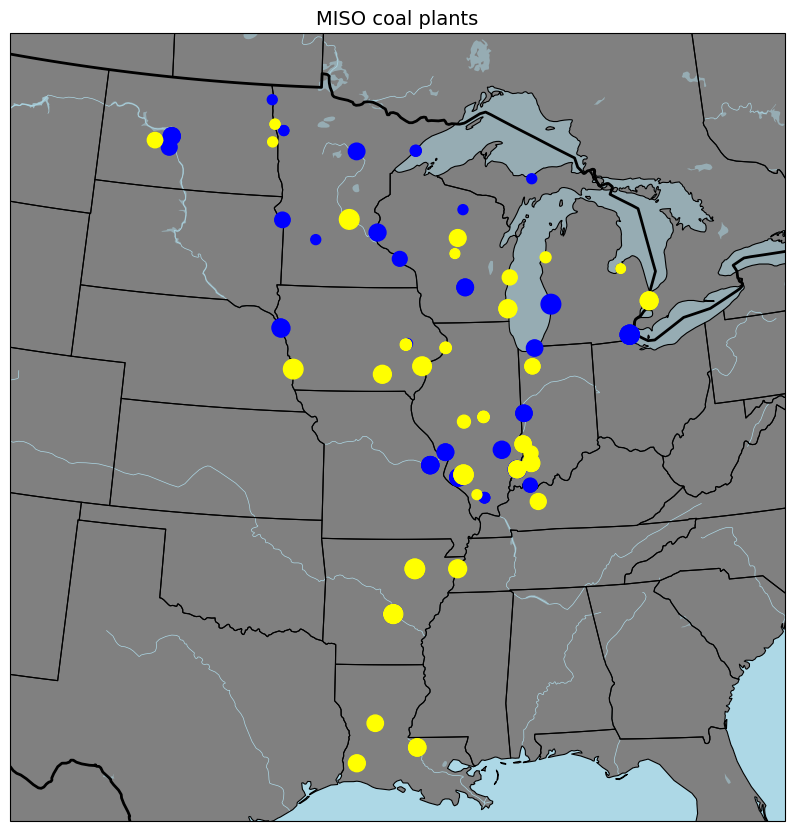

In [189]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Your coordinates with custom labels ---
new_coords = coal_coords_new  # Use the coal_coords list created earlier
old_coords = coal_coords_old  # Use the coal_coords list created earlier

# --- MISO region bounds ---
WEST, EAST   = -104, -80
SOUTH, NORTH =   28, 50

fig, ax = plt.subplots(
    figsize=(10, 12),
    subplot_kw={"projection": ccrs.LambertConformal(
        central_longitude=-92,
        central_latitude=40
    )}
)

ax.set_extent([WEST, EAST, SOUTH, NORTH], crs=ccrs.PlateCarree())

# --- Map features ---
ax.add_feature(cfeature.LAND,    facecolor="gray")
ax.add_feature(cfeature.OCEAN,   facecolor="lightblue")
ax.add_feature(cfeature.LAKES,   facecolor="lightblue", alpha=0.5)
ax.add_feature(cfeature.RIVERS,  edgecolor="lightblue", linewidth=0.5)
ax.add_feature(cfeature.STATES,  edgecolor="black",     linewidth=0.8)
ax.add_feature(cfeature.BORDERS, edgecolor="black",     linewidth=2)

# --- Extract lists from coords ---
old_lats   = [c["lat"]   for c in old_coords]
old_lons   = [c["lon"]   for c in old_coords]
old_labels = [c["label"] for c in old_coords]
old_capacity = [c["capacity"] for c in old_coords]

new_lats   = [c["lat"]   for c in new_coords]
new_lons   = [c["lon"]   for c in new_coords]
new_labels = [c["label"] for c in new_coords]
new_capacity = [c["capacity"] for c in new_coords]

# --- Scale capacity to marker sizes ---
# Adjust the multiplier/exponent to taste depending on your MW range
def scale_sizes(capacities, min_size=50, max_size=200):
    caps = np.array(capacities, dtype=float)
    cmin, cmax = caps.min(), caps.max()
    if cmax == cmin:  # avoid divide-by-zero if all same capacity
        return np.full_like(caps, (min_size + max_size) / 4)
    return min_size + (caps - cmin) / (cmax - cmin) * (max_size - min_size)

old_sizes = scale_sizes(old_capacity)
new_sizes = scale_sizes(new_capacity)

# --- Plot points ---
ax.scatter(
    old_lons, old_lats,
    transform=ccrs.PlateCarree(),
    color="blue",
    s=old_sizes,
    zorder=5,
    label="Set to retire by 2030"
)

ax.scatter(
    new_lons, new_lats,
    transform=ccrs.PlateCarree(),
    color="yellow",
    s=new_sizes,
    zorder=5,
    label="Newer coal plants (operating year > 1980)"
)






## --- Plot labels ---
#for lat, lon, label in zip(old_lats, old_lons, old_labels):
#    ax.text(
#        lon + 0.3, lat + 0.3,
#        transform=ccrs.PlateCarree(),
#        fontsize=8,
#        fontweight="bold",
#        color="black",
#        bbox=dict(
#            facecolor="white",
#            alpha=0.6,
#            edgecolor="none",
#            boxstyle="round,pad=0.2"
#        )
#    )

ax.set_title("MISO coal plants", fontsize=14)

# --- Build a size legend for capacity (MW) ---
# Pick a few representative capacity values spanning the actual data range
all_capacities = np.array(old_capacity + new_capacity, dtype=float)
cap_min, cap_max = all_capacities.min(), all_capacities.max()
legend_caps = np.linspace(cap_min, cap_max, 3)

# Re-scale relative to the *combined* min/max so proxy dots match the real ones
def scale_to_combined(caps_subset):
    return 50 + (np.array(caps_subset) - cap_min) / (cap_max - cap_min) * (150 - 50)
legend_sizes = scale_to_combined(legend_caps)

size_colors = ["#000000", "#000000", "#000000"]  # green, blue, purple
size_handles = [
    plt.scatter([], [], s=s, color=color, alpha=0.8,
                label=f"~{int(round(c))} MW")
    for c, s, color in zip(legend_caps, legend_sizes, size_colors)
]

# --- Combine color legend (categories) and size legend (capacity) ---
#color_handles, color_labels = ax.get_legend_handles_labels()

#color_legend = ax.legend(
#    handles=color_handles,
#    loc="lower right",
#    title="Plant status",
#    framealpha=0.9 ,
#    facecolor="lightgray"
#)
ax.add_artist(color_legend)  # keep this legend when adding the second one

#ax.legend(
#    handles=size_handles,
#    loc="lower left",
#    title="Dot size = Summer capacity (MW)",
#    framealpha=0.9,
#    labelspacing=1.5,
#    borderpad=1.2
#)

plt.tight_layout()
plt.show()